In [1]:
import os
import shutil
import random

random.seed(42)  # Makes our random split reproducible

dataset_path = "data/dataset-resized"
train_path = "data/train"
val_path = "data/val"

classes = [f for f in os.listdir(dataset_path) 
           if os.path.isdir(os.path.join(dataset_path, f))]

print("Classes:", classes)
print("Ready to split!")

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Ready to split!


In [2]:
for cls in classes:
    # Get all images in this class
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)
    
    # Shuffle randomly
    random.shuffle(images)
    
    # 80% train, 20% val
    split = int(0.8 * len(images))
    train_images = images[:split]
    val_images = images[split:]
    
    # Copy to train folder
    for img in train_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(train_path, cls, img)
        shutil.copy(src, dst)
    
    # Copy to val folder
    for img in val_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(val_path, cls, img)
        shutil.copy(src, dst)
    
    print(f"{cls}: {len(train_images)} train | {len(val_images)} val")

print("\nSplit complete!")

cardboard: 322 train | 81 val
glass: 400 train | 101 val
metal: 328 train | 82 val
paper: 475 train | 119 val
plastic: 385 train | 97 val
trash: 109 train | 28 val

Split complete!


In [3]:
print("CLEARBIN DATA SPLIT SUMMARY")
print("=" * 35)

total_train = 0
total_val = 0

for cls in classes:
    train_count = len(os.listdir(os.path.join(train_path, cls)))
    val_count = len(os.listdir(os.path.join(val_path, cls)))
    total_train += train_count
    total_val += val_count
    bar = "█" * (train_count // 20)
    print(f"{cls:10} | {bar} {train_count} train | {val_count} val")

print("=" * 35)
print(f"Total train : {total_train} images")
print(f"Total val   : {total_val} images")
print(f"Split ratio : {round(total_train/(total_train+total_val)*100)}% train / {round(total_val/(total_train+total_val)*100)}% val")

CLEARBIN DATA SPLIT SUMMARY
cardboard  | ████████████████ 322 train | 81 val
glass      | ████████████████████ 400 train | 101 val
metal      | ████████████████ 328 train | 82 val
paper      | ███████████████████████ 475 train | 119 val
plastic    | ███████████████████ 385 train | 97 val
trash      | █████ 109 train | 28 val
Total train : 2019 images
Total val   : 508 images
Split ratio : 80% train / 20% val


In [4]:
# A single neuron - the building block of all neural networks
def neuron(inputs, weights, bias):
    # Multiply each input by its weight and sum them up
    weighted_sum = sum(i * w for i, w in zip(inputs, weights))
    # Add bias
    result = weighted_sum + bias
    return result

# Example: Is this image "plastic"?
# Inputs = pixel values (simplified to 3 numbers)
inputs  = [0.8, 0.2, 0.5]   # pixel brightness values

# Weights = how important each pixel is (learned during training)
weights = [0.5, 0.3, 0.9]   

# Bias = extra adjustment (learned during training)
bias    = 0.1               

output = neuron(inputs, weights, bias)
print("Neuron inputs :", inputs)
print("Neuron weights:", weights)
print("Neuron bias   :", bias)
print("Neuron output :", round(output, 3))
print()
print("This output gets passed to the next layer of neurons!")

Neuron inputs : [0.8, 0.2, 0.5]
Neuron weights: [0.5, 0.3, 0.9]
Neuron bias   : 0.1
Neuron output : 1.01

This output gets passed to the next layer of neurons!


ReLU in action:
-------------------------
  Input:    -3 → Output: 0
  Input:    -1 → Output: 0
  Input:     0 → Output: 0
  Input:   0.5 → Output: 0.5
  Input:  1.01 → Output: 1.01
  Input:     2 → Output: 2
  Input:     5 → Output: 5


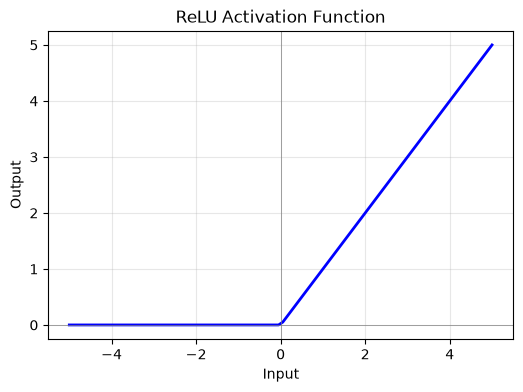

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return max(0, x)

# Test it
test_values = [-3, -1, 0, 0.5, 1.01, 2, 5]

print("ReLU in action:")
print("-" * 25)
for val in test_values:
    output = relu(val)
    print(f"  Input: {val:5} → Output: {output}")

# Plot it
x = np.linspace(-5, 5, 100)
y = np.maximum(0, x)

plt.figure(figsize=(6, 4))
plt.plot(x, y, color='blue', linewidth=2)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# ============================================
# CLEARBIN - DAY 3 NOTES
# ============================================

# 1. Data Split
#    - 80% train (2019 images), 20% val (508 images)
#    - random.seed(42) makes split reproducible
#    - Train = model learns from these
#    - Val = model tested on these (never seen before)

# 2. Overfitting
#    - When model memorizes training data
#    - Performs well on train, badly on new images
#    - Val set helps us detect this

# 3. Neuron
#    - output = sum(input × weight) + bias
#    - Weights and biases are LEARNED during training
#    - Millions of neurons = neural network

# 4. ReLU Activation Function
#    - If input < 0 → output 0
#    - If input > 0 → keep as is
#    - Lets network learn complex patterns
#    - Used after every layer in our ClearBin model

print("Day 3 complete!")

Day 3 complete!
